# Evaluando el Modelo de Regresión

Métricas clave:
- **RMSE** (Root Mean Squared Error): precisión general del modelo
- **RSE** (Residual Standard Error): como RMSE pero ajustado por grados de libertad
- **R²** (Coeficiente de determinación): proporción de varianza explicada (0 a 1)
- **t-statistic**: indica si un predictor es estadísticamente significativo

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
df = pd.read_csv("../data/housing.csv", index_col="id")
df.head()

,square_meters,age,price,bedrooms,bathrooms,floor,distance_to_center_km,has_garage,build_quality
id,,,,,,,,,
1,51,5,152700,2,1,2,4.7,0,5
2,52,44,132300,2,1,10,4.3,1,3
3,56,36,183200,2,1,1,6.6,1,6
4,57,6,170100,3,2,8,14.0,1,5
5,58,21,109500,2,1,1,18.0,1,5


In [13]:
predictors = [
    "square_meters",
    "age",
    "bedrooms",
    "bathrooms",
    "floor",
    "distance_to_center_km",
    "has_garage",
    "build_quality",
]
outcome = "price"

X = df[predictors]
y = df[outcome]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Coeficientes:")
for name, coef in zip(predictors, model.coef_):
    print(f"  {name:>25}: {coef:>10,.2f}")
print(f"\nIntercepto: {model.intercept_:,.2f}")

Coeficientes:
              square_meters:     990.75
                        age:    -669.32
                   bedrooms:  13,469.45
                  bathrooms:  12,130.97
                      floor:      35.21
      distance_to_center_km:  -3,084.00
                 has_garage:  14,117.45
              build_quality:   2,522.18

Intercepto: 69,423.03


---
## 1. RMSE — Root Mean Squared Error

$$\text{RMSE} = \sqrt{\frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{n}}$$

Mide el error promedio del modelo **en las mismas unidades** que la variable objetivo (en este caso, dólares).

In [14]:
# Calculando RMSE a mano
errors = y_test - y_pred
rmse_manual = np.sqrt(np.mean(errors**2))
print(f"RMSE (manual): ${rmse_manual:,.2f}")

# Con sklearn
rmse_sklearn = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (sklearn): ${rmse_sklearn:,.2f}")

print(
    f"\nInterpretación: en promedio, nuestras predicciones se desvían ~${rmse_sklearn:,.0f} del precio real."
)
print(f"Precio promedio del dataset: ${y.mean():,.0f}")
print(f"RMSE como % del precio promedio: {rmse_sklearn / y.mean() * 100:.1f}%")

RMSE (manual): $32,632.24
RMSE (sklearn): $32,632.24

Interpretación: en promedio, nuestras predicciones se desvían ~$32,632 del precio real.
Precio promedio del dataset: $240,206
RMSE como % del precio promedio: 13.6%


---
## 2. RSE — Residual Standard Error

$$\text{RSE} = \sqrt{\frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{n - p - 1}}$$

La diferencia con RMSE es el denominador: usa **grados de libertad** ($n - p - 1$) en vez de $n$.
- $p$ = número de predictores
- Con datasets grandes, RMSE ≈ RSE

In [15]:
n = len(y_test)
p = len(predictors)

rse = np.sqrt(np.sum(errors**2) / (n - p - 1))
print(f"RSE: ${rse:,.2f}")
print(f"RMSE: ${rmse_manual:,.2f}")
print(f"Diferencia: ${abs(rse - rmse_manual):,.2f}")
print(f"\nn={n}, p={p}, grados de libertad={n - p - 1}")
print(f"Con n grande, la diferencia es mínima.")

RSE: $44,001.31
RMSE: $32,632.24
Diferencia: $11,369.06

n=20, p=8, grados de libertad=11
Con n grande, la diferencia es mínima.


---
## 3. R² — Coeficiente de Determinación

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

- **R² = 1**: el modelo explica toda la variación
- **R² = 0**: el modelo no explica nada (tan bueno como predecir la media)
- El denominador es proporcional a la **varianza de Y**

In [16]:
# R² a mano
ss_res = np.sum((y_test - y_pred) ** 2)  # suma de cuadrados de residuos
ss_tot = np.sum((y_test - y_test.mean()) ** 2)  # suma de cuadrados total

r2_manual = 1 - (ss_res / ss_tot)
print(f"R² (manual): {r2_manual:.4f}")

# Con sklearn
r2_sk = r2_score(y_test, y_pred)
print(f"R² (sklearn): {r2_sk:.4f}")

print(f"\nEl modelo explica el {r2_sk * 100:.1f}% de la variación en los precios.")

R² (manual): 0.8263
R² (sklearn): 0.8263

El modelo explica el 82.6% de la variación en los precios.


In [17]:
# R² Ajustado: penaliza agregar más predictores
r2_adj = 1 - (1 - r2_manual) * (n - 1) / (n - p - 1)
print(f"R²:          {r2_manual:.4f}")
print(f"R² Ajustado: {r2_adj:.4f}")
print(f"\nCon pocos predictores y muchos datos, la diferencia es mínima.")

R²:          0.8263
R² Ajustado: 0.6999

Con pocos predictores y muchos datos, la diferencia es mínima.


### Visualización: ¿Qué significa R²?

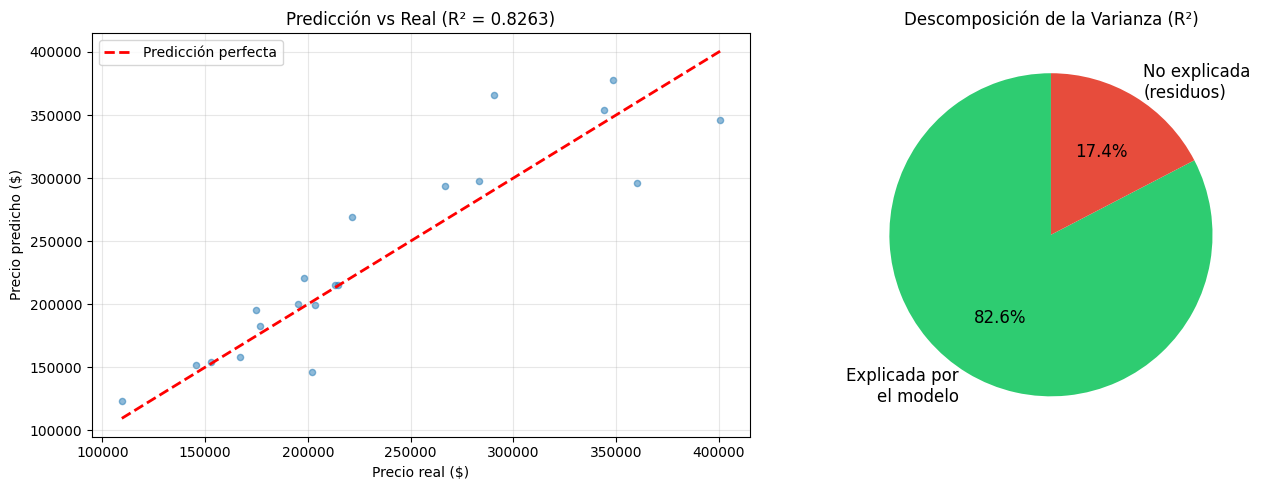

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: predicciones vs real con R²
axes[0].scatter(y_test, y_pred, alpha=0.5, s=20)
min_val, max_val = y_test.min(), y_test.max()
axes[0].plot(
    [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Predicción perfecta"
)
axes[0].set_xlabel("Precio real ($)")
axes[0].set_ylabel("Precio predicho ($)")
axes[0].set_title(f"Predicción vs Real (R² = {r2_sk:.4f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Derecha: descomponer la varianza
labels = ["Explicada por\nel modelo", "No explicada\n(residuos)"]
sizes = [r2_sk, 1 - r2_sk]
colors = ["#2ecc71", "#e74c3c"]
axes[1].pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 12},
)
axes[1].set_title("Descomposición de la Varianza (R²)")

plt.tight_layout()
plt.show()

---
## 4. t-statistic y significancia de coeficientes

$$t_b = \frac{\hat{b}}{SE(\hat{b})}$$

- **t alto** (p-value bajo): el predictor es significativo, **mantenerlo**
- **t bajo** (p-value alto): el predictor podría eliminarse
- Útil para decidir qué variables incluir en el modelo

In [21]:
# statsmodels da un resumen completo como el summary() de R
X_with_const = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_with_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     43.09
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           2.88e-24
Time:                        17:10:51   Log-Likelihood:                -954.61
No. Observations:                  80   AIC:                             1927.
Df Residuals:                      71   BIC:                             1949.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  6.942e+

### Interpretando el summary:

| Columna | Qué significa |
|---------|---------------|
| **coef** | Valor del coeficiente (cuánto cambia el precio por unidad del predictor) |
| **std err** | Error estándar del coeficiente (incertidumbre) |
| **t** | t-statistic = coef / std err |
| **P>\|t\|** | p-value: si es < 0.05, el coeficiente es significativo |
| **[0.025, 0.975]** | Intervalo de confianza del 95% |

In [22]:
# Extraer y visualizar los t-statistics
coef_df = pd.DataFrame(
    {
        "coef": ols_model.params,
        "std_err": ols_model.bse,
        "t_stat": ols_model.tvalues,
        "p_value": ols_model.pvalues,
    }
)
coef_df

,coef,std_err,t_stat,p_value
const,69423.032792,28500.119614,2.435886,0.017367
square_meters,990.750331,240.915719,4.112435,0.000104
age,-669.324933,338.808045,-1.975528,0.052096
bedrooms,13469.448320,9786.639609,1.376310,0.173051
bathrooms,12130.974938,10864.849830,1.116534,0.267958
floor,35.205075,1069.336236,0.032922,0.973829
distance_to_center_km,-3084.004149,658.758621,-4.681539,0.000013
has_garage,14117.449552,9287.398985,1.520065,0.132936
build_quality,2522.183850,3367.777839,0.748916,0.456382


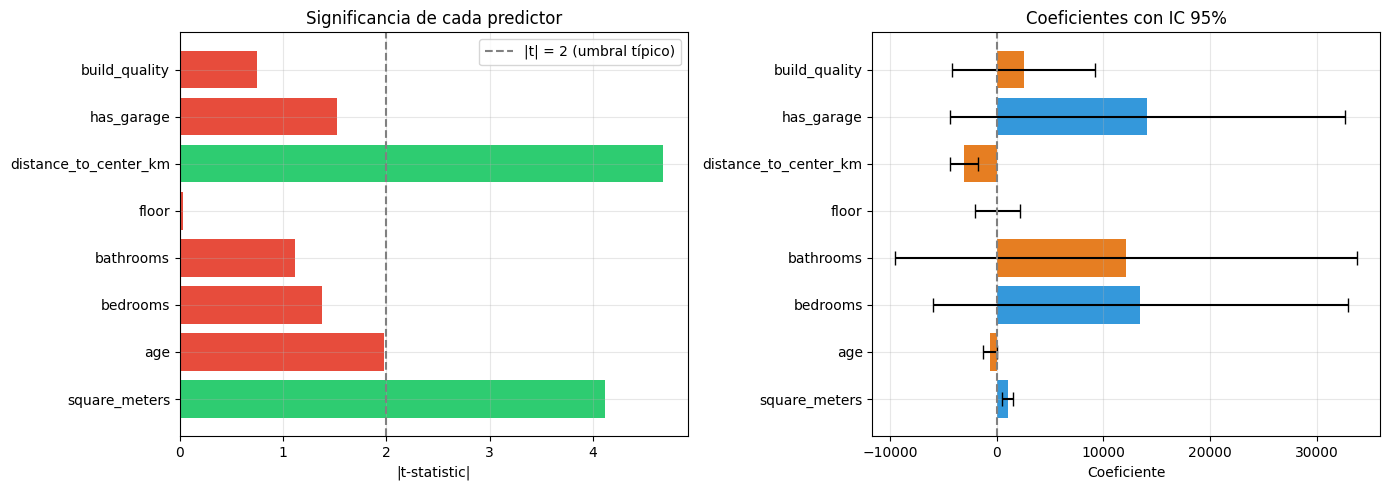

In [23]:
# Visualizar t-statistics (sin el intercepto)
coef_predictors = coef_df.drop("const")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# t-statistics
colors = ["#2ecc71" if abs(t) > 2 else "#e74c3c" for t in coef_predictors["t_stat"]]
axes[0].barh(coef_predictors.index, coef_predictors["t_stat"].abs(), color=colors)
axes[0].axvline(x=2, color="gray", linestyle="--", label="|t| = 2 (umbral típico)")
axes[0].set_xlabel("|t-statistic|")
axes[0].set_title("Significancia de cada predictor")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Coeficientes con intervalos de confianza
conf = ols_model.conf_int().drop("const")
conf.columns = ["lower", "upper"]
mid = coef_predictors["coef"]
err = [(mid - conf["lower"]).values, (conf["upper"] - mid).values]

axes[1].barh(
    coef_predictors.index, mid, xerr=err, color=["#3498db", "#e67e22"], capsize=5
)
axes[1].axvline(x=0, color="gray", linestyle="--")
axes[1].set_xlabel("Coeficiente")
axes[1].set_title("Coeficientes con IC 95%")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Comparando modelos con RMSE

RMSE es la métrica principal para comparar modelos. Veamos cómo mejora al ir agregando predictores.

In [27]:
results = []

predictor_sets = {
    "solo square_meters": ["square_meters"],
    "m² + age": ["square_meters", "age"],
    "m² + age + location": ["square_meters", "age", "distance_to_center_km"],
    "m² + age + location + quality": [
        "square_meters",
        "age",
        "distance_to_center_km",
        "build_quality",
    ],
    "todos los predictores": predictors,
}

for name, preds in predictor_sets.items():
    m = LinearRegression()
    m.fit(X_train[preds], y_train)
    pred = m.predict(X_test[preds])
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results.append(
        {
            "Modelo": name,
            "Predictores": len(preds),
            "RMSE": f"${rmse:,.0f}",
            "R²": f"{r2:.4f}",
        }
    )

pd.DataFrame(results)

,Modelo,Predictores,RMSE,R²
0,solo square_meters,1,"$33,722",0.8144
1,m² + age,2,"$37,415",0.7716
2,m² + age + location,3,"$36,795",0.7791
3,m² + age + location + quality,4,"$36,248",0.7856
4,todos los predictores,8,"$32,632",0.8263


---
## 6. Calculando t-statistic a mano

Para confirmar que entendemos la fórmula $t_b = \frac{\hat{b}}{SE(\hat{b})}$:

In [25]:
for predictor in ["const"] + predictors:
    coef = ols_model.params[predictor]
    se = ols_model.bse[predictor]
    t_manual = coef / se
    t_model = ols_model.tvalues[predictor]
    print(
        f"{predictor:>25}: coef={coef:>12.2f}, SE={se:>10.2f}, t(manual)={t_manual:>8.3f}, t(modelo)={t_model:>8.3f}"
    )

                    const: coef=    69423.03, SE=  28500.12, t(manual)=   2.436, t(modelo)=   2.436
            square_meters: coef=      990.75, SE=    240.92, t(manual)=   4.112, t(modelo)=   4.112
                      age: coef=     -669.32, SE=    338.81, t(manual)=  -1.976, t(modelo)=  -1.976
                 bedrooms: coef=    13469.45, SE=   9786.64, t(manual)=   1.376, t(modelo)=   1.376
                bathrooms: coef=    12130.97, SE=  10864.85, t(manual)=   1.117, t(modelo)=   1.117
                    floor: coef=       35.21, SE=   1069.34, t(manual)=   0.033, t(modelo)=   0.033
    distance_to_center_km: coef=    -3084.00, SE=    658.76, t(manual)=  -4.682, t(modelo)=  -4.682
               has_garage: coef=    14117.45, SE=   9287.40, t(manual)=   1.520, t(modelo)=   1.520
            build_quality: coef=     2522.18, SE=   3367.78, t(manual)=   0.749, t(modelo)=   0.749


---
## Resumen

| Métrica | Para qué sirve | Valor ideal |
|---------|----------------|-------------|
| **RMSE** | Comparar modelos, medir precisión | Menor = mejor |
| **RSE** | Igual que RMSE, ajustado por grados de libertad | Menor = mejor |
| **R²** | Proporción de varianza explicada | Más cerca de 1 = mejor |
| **t-statistic** | ¿El predictor es significativo? | \|t\| > 2 suele indicar significancia |